# Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

Используем данные о [пассажирах титаника](https://www.kaggle.com/competitions/titanic/data)

In [2]:
data = pd.read_csv('train.csv', sep=",")

In [3]:
data.shape

(891, 12)

In [4]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [5]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Обработка пропусков в данных

In [7]:
# Удаление колонок, содержащих пустые значения
data_new_1 = data.dropna(axis=1, how='any')
(data.shape, data_new_1.shape)

((891, 12), (891, 9))

In [8]:
# Удаление строк, содержащих пустые значения
data_new_2 = data.dropna(axis=0, how='any')
(data.shape, data_new_2.shape)

((891, 12), (183, 12))

### Обработка пропусков в числовых данных

In [11]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
num_cols = []
total_count = data.shape[0]
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Age. Тип данных float64. Количество пустых значений 177, 19.87%.


In [12]:
# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


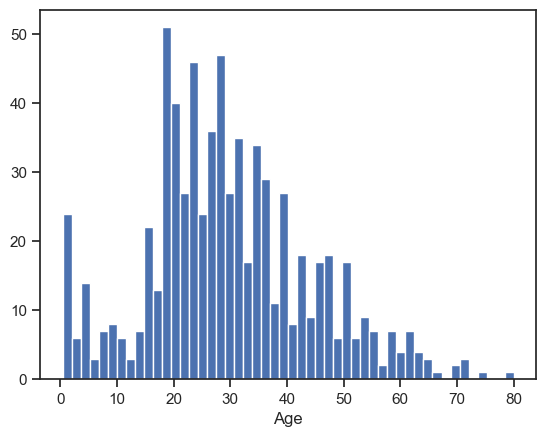

In [13]:
# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [37]:
# Фильтр для проверки заполнения пустых значений
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num)
mask_missing_values_only[:10]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False]])

In [16]:
strategies=['mean', 'median', 'most_frequent']

In [18]:
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num)
    return data_num_imp[mask_missing_values_only]

In [36]:
strategies[0], test_num_impute(strategies[0])[:5]

('mean',
 array([29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765]))

In [35]:
strategies[1], test_num_impute(strategies[1])[:5]

('median', array([28., 28., 28., 28., 28.]))

In [34]:
strategies[2], test_num_impute(strategies[2])[:5]

('most_frequent', array([24., 24., 24., 24., 24.]))

### Обработка пропусков в категориальных данных

In [24]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Cabin. Тип данных object. Количество пустых значений 687, 77.1%.
Колонка Embarked. Тип данных object. Количество пустых значений 2, 0.22%.


In [33]:
cat_temp_data = data[['Embarked']]
cat_temp_data.head()

,Embarked
0,S
1,C
2,S
3,S
4,S


In [26]:
cat_temp_data['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [27]:
cat_temp_data[cat_temp_data['Embarked'].isnull()].shape

(2, 1)

In [31]:
# Импьютация наиболее частыми значениями
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(cat_temp_data)
data_imp2[:20]

array([['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['S'],
       ['C']], dtype=object)

In [40]:
# Пустые значения отсутствуют
np.unique(data_imp2)

array(['C', 'Q', 'S'], dtype=object)

## Преобразование категориальных признаков в числовые

In [41]:
cat_enc = pd.DataFrame({'c1':data_imp2.T[0]})
cat_enc

,c1
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [42]:
from sklearn.preprocessing import OrdinalEncoder

In [46]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(cat_enc)
cat_enc_oe[:10]

array([[2.],
       [0.],
       [2.],
       [2.],
       [2.],
       [1.],
       [2.],
       [2.],
       [2.],
       [0.]])

In [49]:
np.unique(cat_enc_oe[:, 0])

array([0., 1., 2.])

In [51]:
# Обратное преобразование
oe.inverse_transform(cat_enc_oe)[:10]

array([['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['S'],
       ['S'],
       ['C']], dtype=object)

## Масштабирование данных

In [52]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

In [53]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Age']])

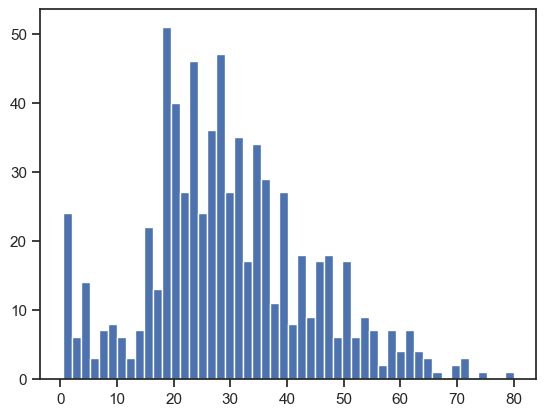

In [54]:
plt.hist(data['Age'], 50)
plt.show()

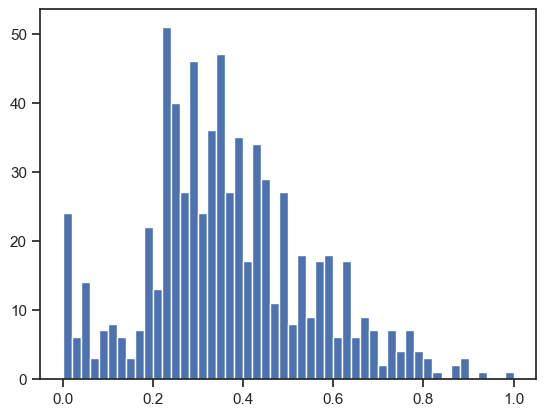

In [55]:
plt.hist(sc1_data, 50)
plt.show()

In [56]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['Age']])

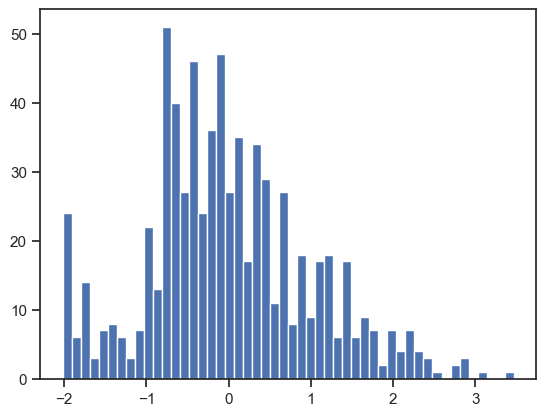

In [57]:
plt.hist(sc2_data, 50)
plt.show()